In [48]:
import pandas as pd
path   = "/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/src/keras/predictions_fnn_with_target_TF.csv"
df_final = pd.read_csv(path)
df_final.head()

,CODIGO_FAMILIA,COD_SUBCATEGORIA,NOMBRE_SUBCATEGORIA,recencia_hl,freq_baja,freq_media,freq_alta,cv_invertido,Ciclos_cv,sow_24m,season_ratio,ciclo_min,ciclo_promedio,ciclo_max,Ciclos_ciclo_dias,Ciclos_gaps_normalizados,Ciclos_tipo_ciclo,fnn_prob,target
0,1759533761,9598,PREV. SOLAR COSMETICO PROTECCION FACIAL,0.000000,0,0,0,0.000000,999.000000,0.016129,0.00,0.000000,0.000000,0.000000,"[0, 0, 0]",[],no_ciclico,0.019809,0
1,1759533761,9416,MULTIVITAMINICOS OTC,0.000000,0,0,0,0.000000,999.000000,0.053763,0.00,0.000000,0.000000,0.000000,"[0, 0, 0]",[],no_ciclico,0.030201,0
2,1759533761,8792,COLACIONES Y SNACKS BIENESTAR,0.000000,0,0,0,0.111973,0.888027,1.000000,0.00,0.000000,0.000000,0.000000,"[0, 0, 0]","[14.0, 13.0, 2.0, 1.0, 6.0, 3.0, 2.0, 2.0, 4.0]",no_ciclico,0.236098,0
3,1759533761,6846,ANTIINFLAMATORIOS SISTEMICOS,0.000000,0,0,0,0.109624,0.890376,0.263441,0.00,0.000000,0.000000,0.000000,"[0, 0, 0]","[4.0, 1.0, 8.0, 14.0, 2.0, 22.0, 8.0, 29.0, 4.0]",no_ciclico,0.124060,0
4,1759533761,2384,DOLOR Y FIEBRE ANALGESIA,0.849601,1,1,0,0.466169,0.533831,0.145161,0.99,116.733333,137.333333,199.133333,"[116.73333333333333, 137.33333333333334, 199.1...","[5.8, 5.0, 1.0]",mediano,0.212598,0


In [39]:
df_final['rank_prob'] = df_final.groupby(['CODIGO_FAMILIA'])["fnn_prob"].rank(method="first", ascending=False)
df_final['recomendacion'] = (df_final['rank_prob'] <= 3).astype(int)


In [44]:
columnas_usar = ['fnn_prob','target','Ciclos_tipo_ciclo','recomendacion']
df_analisis = df_final[columnas_usar].copy()
df_analisis['score_round'] = df_analisis['fnn_prob'].round(1)

df_analisis_group_total = df_analisis.groupby(['score_round']).agg(
    Total_general=('target', 'count'),
    target_1=('target', lambda x: (x==1).sum()),
    target_0=('target', lambda x: (x==0).sum()),
    recomendacion_1=('recomendacion', lambda x: (x==1).sum()),
    recomendacion_0=('recomendacion', lambda x: (x==0).sum()),
    target1_reco1=('target', lambda x: ((x==1) & (df_analisis.loc[x.index, 'recomendacion'].eq(1))).sum())

).reset_index()



In [46]:
df_analisis_group_total['P_compra_21_1' ] = round(df_analisis_group_total['target_1']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['P_compra_21_0' ] = round(df_analisis_group_total['target_0']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['Acertividad'] = round(df_analisis_group_total['target1_reco1'] / df_analisis_group_total['target_1']*100,2)
df_analisis_group_total[['score_round','Total_general','target_1','target_0','target1_reco1','Acertividad'] ]

,score_round,Total_general,target_1,target_0,target1_reco1,Acertividad
0,0.0,207888,5554,202334,1,0.02
1,0.1,52837,5251,47586,38,0.72
2,0.2,11265,2442,8823,363,14.86
3,0.3,5759,1988,3771,736,37.02
4,0.4,3224,1503,1721,1292,85.96
5,0.5,1185,681,504,674,98.97
6,0.6,133,79,54,79,100.00


In [ ]:
(5554/207888) *100
()

2.671630878165166

## Matriz de confusión de las caracteriscas contra fnn_prob

ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES

📂 Cargando predictions_fnn_with_target.csv...
   ✓ 282291 registros

📊 Calculando correlaciones...
   Features analizadas: 7
   Registros: 282291

📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB

Feature               Correlación Barra                         
-----------------------------------------------------------------
sow_24m              +    0.8688  ██████████████████████████
season_ratio         +    0.7573  ██████████████████████
recencia_hl          +    0.6478  ███████████████████
freq_baja            +    0.6239  ██████████████████
cv_invertido         +    0.5388  ████████████████
freq_media           +    0.4899  ██████████████
freq_alta            +    0.1583  ████

💾 Guardado: correlaciones_fnn.csv

📊 MATRIZ DE CORRELACIÓN COMPLETA
              recencia_hl  freq_baja  freq_media  freq_alta  cv_invertido  \
recencia_hl        1.0000     0.7519      0.7083     0.3939        0.4764   
freq_baja          0.7519     1.0000      0.

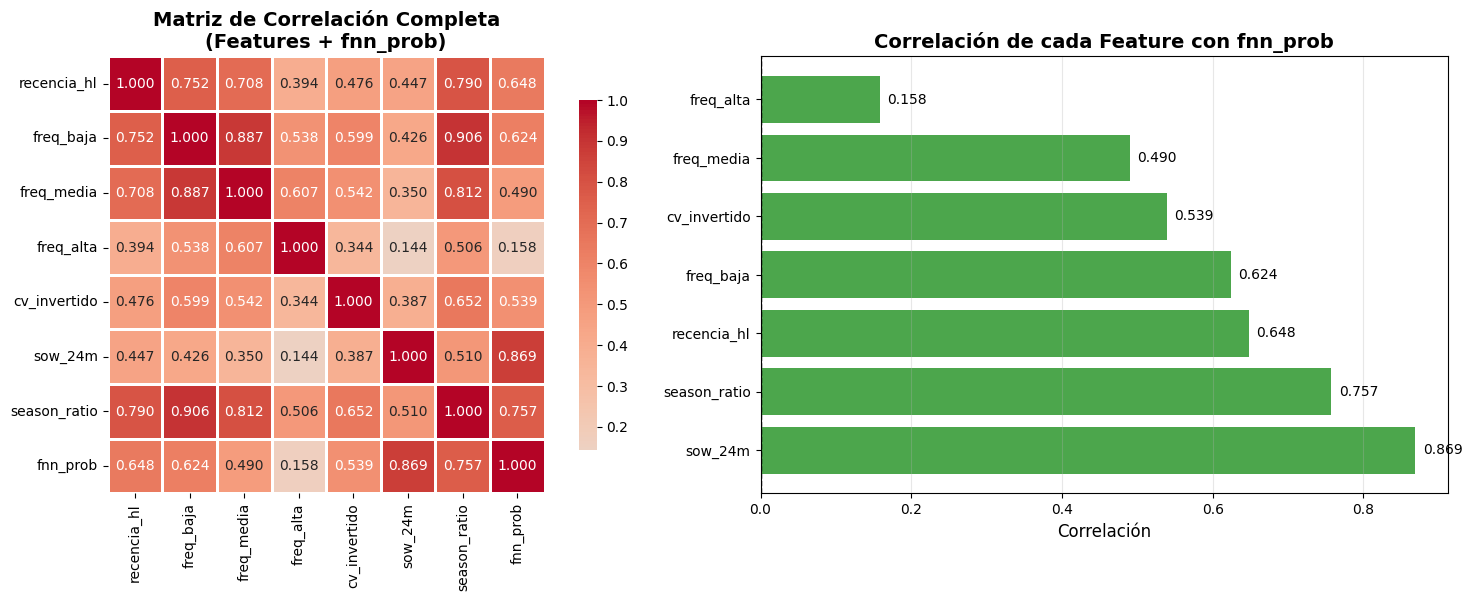

In [47]:
"""
Análisis de correlación: fnn_prob vs 7 features
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    print("=" * 80)
    print("ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES")
    print("=" * 80)
    
    # Cargar archivo
    print("\n📂 Cargando predictions_fnn_with_target.csv...")
    df = df_final.copy()
    print(f"   ✓ {len(df)} registros")
    
    # 7 features del modelo
    features = [
        'recencia_hl',
        'freq_baja',
        'freq_media',
        'freq_alta',
        'cv_invertido',
        'sow_24m',
        'season_ratio'
    ]
    
    # Agregar fnn_prob para correlación
    cols_correlacion = features + ['fnn_prob']
    
    # Filtrar solo columnas numéricas
    df_corr = df[cols_correlacion].copy()
    
    print(f"\n📊 Calculando correlaciones...")
    print(f"   Features analizadas: {len(features)}")
    print(f"   Registros: {len(df_corr)}")
    
    # Matriz de correlación completa
    corr_matrix = df_corr.corr()
    
    # Extraer solo correlaciones con fnn_prob
    corr_with_prob = corr_matrix['fnn_prob'].drop('fnn_prob').sort_values(ascending=False)
    
    print("\n" + "=" * 80)
    print("📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB")
    print("=" * 80)
    
    print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
    print("-" * 65)
    
    for feature, corr in corr_with_prob.items():
        # Barra visual
        bar_length = int(abs(corr) * 30)
        bar = "█" * bar_length
        sign = "+" if corr >= 0 else "-"
        
        print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
    
    # Guardar correlaciones en CSV
    corr_df = pd.DataFrame({
        'feature': corr_with_prob.index,
        'correlacion': corr_with_prob.values
    })
    corr_df.to_csv('correlaciones_fnn.csv', index=False)
    print(f"\n💾 Guardado: correlaciones_fnn.csv")
    
    # Matriz completa
    print("\n" + "=" * 80)
    print("📊 MATRIZ DE CORRELACIÓN COMPLETA")
    print("=" * 80)
    print(corr_matrix.round(4))
    
    corr_matrix.to_csv('matriz_correlacion_completa.csv')
    print(f"\n💾 Guardado: matriz_correlacion_completa.csv")
    
    # Visualización
    print("\n🎨 Generando visualización...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Heatmap de matriz completa
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[0])
    axes[0].set_title('Matriz de Correlación Completa\n(Features + fnn_prob)', 
                      fontsize=14, fontweight='bold')
    
    # 2. Barras de correlación con fnn_prob
    colors = ['green' if x > 0 else 'red' for x in corr_with_prob.values]
    axes[1].barh(range(len(corr_with_prob)), corr_with_prob.values, color=colors, alpha=0.7)
    axes[1].set_yticks(range(len(corr_with_prob)))
    axes[1].set_yticklabels(corr_with_prob.index)
    axes[1].set_xlabel('Correlación', fontsize=12)
    axes[1].set_title('Correlación de cada Feature con fnn_prob', 
                      fontsize=14, fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Agregar valores en las barras
    for i, v in enumerate(corr_with_prob.values):
        axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('correlacion_features_fnn.png', dpi=150, bbox_inches='tight')
    print(f"   ✓ Guardado: correlacion_features_fnn.png")
    
    # Análisis adicional: correlación con target
    if 'target' in df.columns:
        print("\n" + "=" * 80)
        print("🎯 CORRELACIÓN CON TARGET (compras reales)")
        print("=" * 80)
        
        cols_target = features + ['fnn_prob', 'target']
        corr_target = df[cols_target].corr()['target'].drop('target').sort_values(ascending=False)
        
        print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
        print("-" * 65)
        
        for feature, corr in corr_target.items():
            bar_length = int(abs(corr) * 30)
            bar = "█" * bar_length
            sign = "+" if corr >= 0 else "-"
            print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
        
        # Comparación lado a lado
        comparison = pd.DataFrame({
            'feature': corr_with_prob.index,
            'corr_con_fnn_prob': corr_with_prob.values,
            'corr_con_target': [corr_target[f] for f in corr_with_prob.index]
        })
        comparison.to_csv('comparacion_correlaciones.csv', index=False)
        print(f"\n💾 Guardado: comparacion_correlaciones.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANÁLISIS COMPLETADO")
    print("=" * 80)
    
    print("\n📁 Archivos generados:")
    print("   1. correlaciones_fnn.csv - Correlación features vs fnn_prob")
    print("   2. matriz_correlacion_completa.csv - Matriz completa")
    print("   3. correlacion_features_fnn.png - Visualización")
    if 'target' in df.columns:
        print("   4. comparacion_correlaciones.csv - Comparación fnn_prob vs target")
    
    print("\n💡 Interpretación:")
    print("   - Valores cercanos a +1: correlación positiva fuerte")
    print("   - Valores cercanos a -1: correlación negativa fuerte")
    print("   - Valores cercanos a 0: sin correlación")
    print("=" * 80)


if __name__ == "__main__":
    main()


### Análisis con familias con mayores ventas solo 665 primeras familias

In [2]:
import pandas as pd
path   = "/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/src/keras/predictions_fnn_with_target.csv"
df_final = pd.read_csv(path)
df_final.head()
df_final['rank_prob'] = df_final.groupby(['CODIGO_FAMILIA'])["fnn_prob"].rank(method="first", ascending=False)
df_final['recomendacion'] = (df_final['rank_prob'] <= 3).astype(int)
columnas_usar = ['fnn_prob','target','Ciclos_tipo_ciclo','recomendacion']
df_analisis = df_final[columnas_usar].copy()
df_analisis['score_round'] = df_analisis['fnn_prob'].round(1)

df_analisis_group_total = df_analisis.groupby(['score_round']).agg(
    Total_general=('target', 'count'),
    target_1=('target', lambda x: (x==1).sum()),
    target_0=('target', lambda x: (x==0).sum()),
    recomendacion_1=('recomendacion', lambda x: (x==1).sum()),
    recomendacion_0=('recomendacion', lambda x: (x==0).sum()),
    target1_reco1=('target', lambda x: ((x==1) & (df_analisis.loc[x.index, 'recomendacion'].eq(1))).sum())

).reset_index()
df_analisis_group_total['P_compra_21_1' ] = round(df_analisis_group_total['target_1']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['P_compra_21_0' ] = round(df_analisis_group_total['target_0']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['Acertividad'] = round(df_analisis_group_total['target1_reco1'] / df_analisis_group_total['target_1']*100,2)
df_analisis_group_total[['score_round','Total_general','target_1','target_0','target1_reco1','Acertividad'] ]


,score_round,Total_general,target_1,target_0,target1_reco1,Acertividad
0,0.0,61290,1613,59677,0,0.00
1,0.1,19102,1843,17259,0,0.00
2,0.2,4625,956,3669,2,0.21
3,0.3,2861,884,1977,32,3.62
4,0.4,1753,751,1002,180,23.97
5,0.5,1064,607,457,459,75.62
6,0.6,466,319,147,317,99.37
7,0.7,55,38,17,38,100.00


ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES

📂 Cargando predictions_fnn_with_target.csv...
   ✓ 91216 registros

📊 Calculando correlaciones...
   Features analizadas: 7
   Registros: 91216

📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB

Feature               Correlación Barra                         
-----------------------------------------------------------------
sow_24m              +    0.8993  ██████████████████████████
season_ratio         +    0.7765  ███████████████████████
recencia_hl          +    0.6811  ████████████████████
freq_baja            +    0.6236  ██████████████████
cv_invertido         +    0.5200  ███████████████
freq_media           +    0.4787  ██████████████
freq_alta            +    0.1665  ████

💾 Guardado: correlaciones_fnn.csv

📊 MATRIZ DE CORRELACIÓN COMPLETA
              recencia_hl  freq_baja  freq_media  freq_alta  cv_invertido  \
recencia_hl        1.0000     0.7493      0.7009     0.3803        0.4694   
freq_baja          0.7493     1.0000      0.8

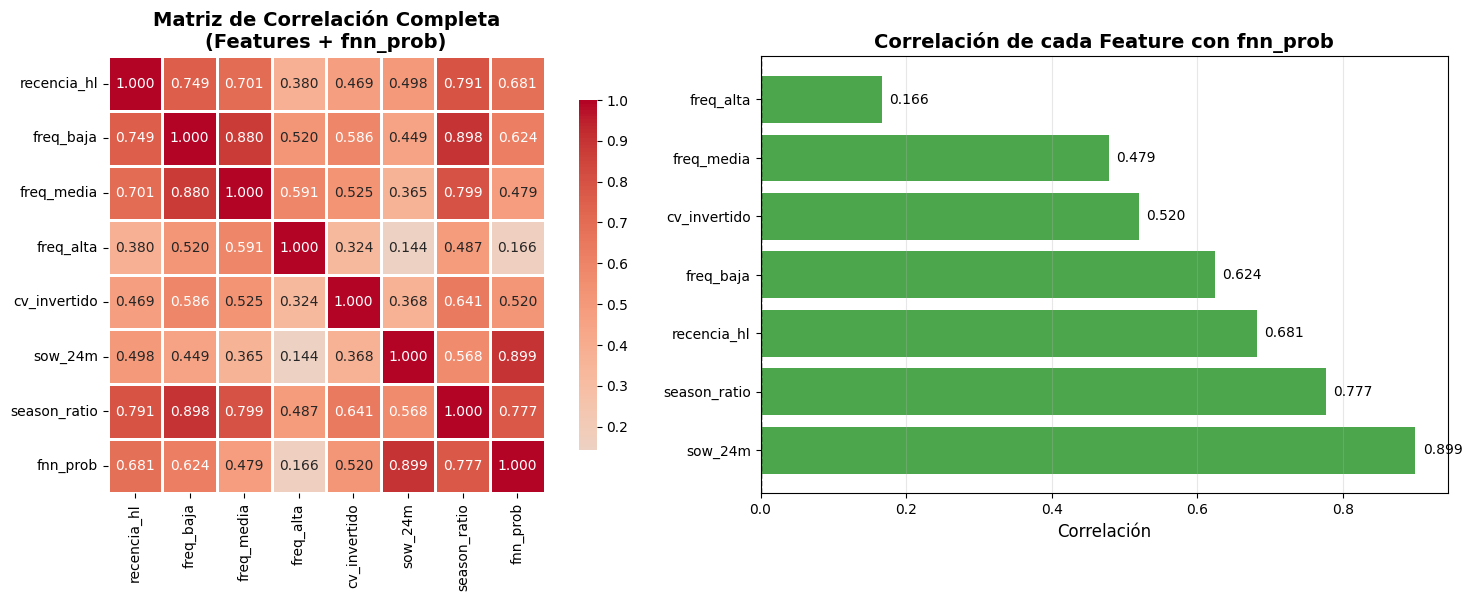

In [4]:
"""
Análisis de correlación: fnn_prob vs 7 features
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    print("=" * 80)
    print("ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES")
    print("=" * 80)
    
    # Cargar archivo
    print("\n📂 Cargando predictions_fnn_with_target.csv...")
    df = df_final.copy()
    print(f"   ✓ {len(df)} registros")
    
    # 7 features del modelo
    features = [
        'recencia_hl',
        'freq_baja',
        'freq_media',
        'freq_alta',
        'cv_invertido',
        'sow_24m',
        'season_ratio'
    ]
    
    # Agregar fnn_prob para correlación
    cols_correlacion = features + ['fnn_prob']
    
    # Filtrar solo columnas numéricas
    df_corr = df[cols_correlacion].copy()
    
    print(f"\n📊 Calculando correlaciones...")
    print(f"   Features analizadas: {len(features)}")
    print(f"   Registros: {len(df_corr)}")
    
    # Matriz de correlación completa
    corr_matrix = df_corr.corr()
    
    # Extraer solo correlaciones con fnn_prob
    corr_with_prob = corr_matrix['fnn_prob'].drop('fnn_prob').sort_values(ascending=False)
    
    print("\n" + "=" * 80)
    print("📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB")
    print("=" * 80)
    
    print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
    print("-" * 65)
    
    for feature, corr in corr_with_prob.items():
        # Barra visual
        bar_length = int(abs(corr) * 30)
        bar = "█" * bar_length
        sign = "+" if corr >= 0 else "-"
        
        print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
    
    # Guardar correlaciones en CSV
    corr_df = pd.DataFrame({
        'feature': corr_with_prob.index,
        'correlacion': corr_with_prob.values
    })
    corr_df.to_csv('correlaciones_fnn.csv', index=False)
    print(f"\n💾 Guardado: correlaciones_fnn.csv")
    
    # Matriz completa
    print("\n" + "=" * 80)
    print("📊 MATRIZ DE CORRELACIÓN COMPLETA")
    print("=" * 80)
    print(corr_matrix.round(4))
    
    corr_matrix.to_csv('matriz_correlacion_completa.csv')
    print(f"\n💾 Guardado: matriz_correlacion_completa.csv")
    
    # Visualización
    print("\n🎨 Generando visualización...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Heatmap de matriz completa
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[0])
    axes[0].set_title('Matriz de Correlación Completa\n(Features + fnn_prob)', 
                      fontsize=14, fontweight='bold')
    
    # 2. Barras de correlación con fnn_prob
    colors = ['green' if x > 0 else 'red' for x in corr_with_prob.values]
    axes[1].barh(range(len(corr_with_prob)), corr_with_prob.values, color=colors, alpha=0.7)
    axes[1].set_yticks(range(len(corr_with_prob)))
    axes[1].set_yticklabels(corr_with_prob.index)
    axes[1].set_xlabel('Correlación', fontsize=12)
    axes[1].set_title('Correlación de cada Feature con fnn_prob', 
                      fontsize=14, fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Agregar valores en las barras
    for i, v in enumerate(corr_with_prob.values):
        axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('correlacion_features_fnn.png', dpi=150, bbox_inches='tight')
    print(f"   ✓ Guardado: correlacion_features_fnn.png")
    
    # Análisis adicional: correlación con target
    if 'target' in df.columns:
        print("\n" + "=" * 80)
        print("🎯 CORRELACIÓN CON TARGET (compras reales)")
        print("=" * 80)
        
        cols_target = features + ['fnn_prob', 'target']
        corr_target = df[cols_target].corr()['target'].drop('target').sort_values(ascending=False)
        
        print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
        print("-" * 65)
        
        for feature, corr in corr_target.items():
            bar_length = int(abs(corr) * 30)
            bar = "█" * bar_length
            sign = "+" if corr >= 0 else "-"
            print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
        
        # Comparación lado a lado
        comparison = pd.DataFrame({
            'feature': corr_with_prob.index,
            'corr_con_fnn_prob': corr_with_prob.values,
            'corr_con_target': [corr_target[f] for f in corr_with_prob.index]
        })
        comparison.to_csv('comparacion_correlaciones.csv', index=False)
        print(f"\n💾 Guardado: comparacion_correlaciones.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANÁLISIS COMPLETADO")
    print("=" * 80)
    
    print("\n📁 Archivos generados:")
    print("   1. correlaciones_fnn.csv - Correlación features vs fnn_prob")
    print("   2. matriz_correlacion_completa.csv - Matriz completa")
    print("   3. correlacion_features_fnn.png - Visualización")
    if 'target' in df.columns:
        print("   4. comparacion_correlaciones.csv - Comparación fnn_prob vs target")
    
    print("\n💡 Interpretación:")
    print("   - Valores cercanos a +1: correlación positiva fuerte")
    print("   - Valores cercanos a -1: correlación negativa fuerte")
    print("   - Valores cercanos a 0: sin correlación")
    print("=" * 80)


if __name__ == "__main__":
    main()
